In [5]:
#Make directory
!mkdir -p ~/.kaggle # Create folder for dataset
!cp kaggle.json ~/.kaggle/ #copy fordel / Take permission

In [6]:
# Download dataset from kaggle
!kaggle datasets download -d emmarex/plantdisease

Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown
plantdisease.zip: Skipping, found more recently modified local copy (use --force to force download)


In [7]:
#unzip files
import zipfile

zip_ref = zipfile.ZipFile('/content/plantdisease.zip', 'r')
zip_ref.extractall('/content/')
zip_ref.close()

In [8]:
from tensorflow import keras
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Flatten
import matplotlib.pyplot as plt
import numpy as np
import cv2

In [9]:
# Generators (Creating batches as the dataset is large)
train = keras.utils.image_dataset_from_directory(
    directory = '/content/PlantVillage',
    labels = 'inferred',
    label_mode = 'categorical',   # 15 classes hain isliye categorical
    batch_size = 32,
    image_size = (256, 256),
    validation_split = 0.2,
    subset = 'training',
    seed = 42
)

test = keras.utils.image_dataset_from_directory(
    directory = '/content/PlantVillage',
    labels = 'inferred',
    label_mode = 'categorical',
    batch_size = 32,
    image_size = (256, 256),
    validation_split = 0.2,
    subset = 'validation',
    seed = 42
)

# Class names print karo
class_names = train.class_names
print("Total Classes:", len(class_names))
print(class_names)

Found 20638 files belonging to 15 classes.
Using 16511 files for training.
Found 20638 files belonging to 15 classes.
Using 4127 files for validation.
Total Classes: 15
['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


In [10]:
for image, labels in train.take(1):
    print(image.shape)
    print(labels.shape)

(32, 256, 256, 3)
(32, 15)


In [11]:
# Data normalization (0-255 ko 0-1 mein convert karo)
train_norm = train.map(lambda image, label: (image/255, label))
test_norm = test.map(lambda image, label: (image/255, label))

In [12]:
# Create model
model = Sequential()

model.add(Conv2D(32, kernel_size=(3,3), padding='valid', activation='relu', input_shape=(256,256,3)))
model.add(MaxPool2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Conv2D(64, kernel_size=(3,3), padding='valid', activation='relu'))
model.add(MaxPool2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Conv2D(128, kernel_size=(3,3), padding='valid', activation='relu'))
model.add(MaxPool2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Flatten())
model.add(Dense(units=128, activation='relu'))
model.add(Dense(units=64, activation='relu'))
model.add(Dense(units=15, activation='softmax'))  # 15 classes, softmax

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',  # multi-class isliye
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 15)             │           975 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,207 (56.64 MB)

 Trainable params: 14,848,207 (56.64 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history = model.fit(train_norm, epochs=10, validation_data=test_norm)

Epoch 1/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 56s 89ms/step - accuracy: 0.6061 - loss: 1.2083 - val_accuracy: 0.7684 - val_loss: 0.7084
Epoch 2/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 38s 75ms/step - accuracy: 0.8414 - loss: 0.4727 - val_accuracy: 0.8561 - val_loss: 0.4122
Epoch 3/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 37s 72ms/step - accuracy: 0.9076 - loss: 0.2751 - val_accuracy: 0.8457 - val_loss: 0.4897
Epoch 4/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 38s 73ms/step - accuracy: 0.9457 - loss: 0.1612 - val_accuracy: 0.8503 - val_loss: 0.4914
Epoch 5/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 37s 72ms/step - accuracy: 0.9620 - loss: 0.1110 - val_accuracy: 0.8609 - val_loss: 0.5546
Epoch 6/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 41s 80ms/step - accuracy: 0.9746 - loss: 0.0788 - val_accuracy: 0.8580 - val_loss: 0.5728
Epoch 7/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 80s 77ms/step - accuracy: 0.9731 - loss: 0.0762 - val_accuracy: 0.8810 - val_loss: 0.5089
Epoch 8/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 38s 74ms/step - accuracy: 0.9790 - loss: 0.0613 - 

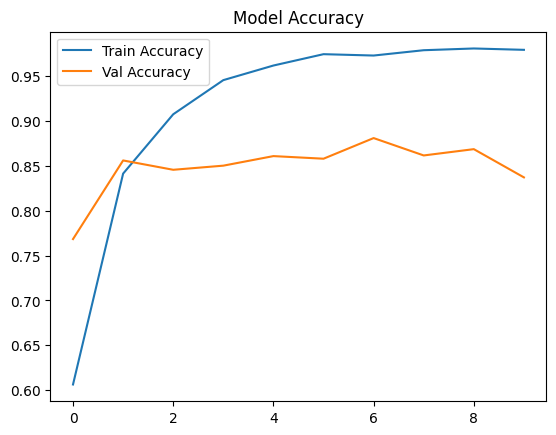

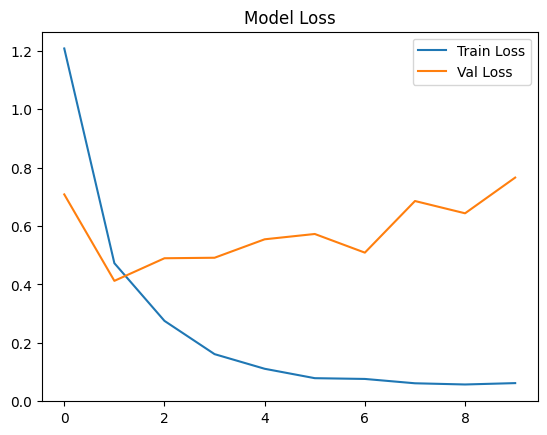

In [14]:
# Accuracy plot
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('Model Accuracy')
plt.show()

# Loss plot
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Model Loss')
plt.show()

In [ ]:
# Koi bhi leaf image upload karo /content/ mein
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Test image load karo
img = cv2.imread('/content/test_leaf.jpg')
plt.imshow(img)
plt.show()
print("Original Shape:", img.shape)

# Resize karo
img = cv2.resize(img, (256, 256))
img = img / 255.0  # normalize

# Prediction
img_input = img.reshape(1, 256, 256, 3)
prediction = model.predict(img_input)

predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction) * 100

print(f"\nPredicted Disease : {predicted_class}")
print(f"Confidence        : {confidence:.2f}%")

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.85      0.61      0.72       200
                     Pepper__bell___healthy       0.77      0.99      0.86       302
                      Potato___Early_blight       0.77      0.96      0.86       189
                       Potato___Late_blight       0.88      0.65      0.75       188
                           Potato___healthy       0.78      0.45      0.57        31
                      Tomato_Bacterial_spot       0.96      0.88      0.92       441
                        Tomato_Early_blight       0.58      0.78      0.66       191
                         Tomato_Late_blight       0.70      0.86      0.77       341
                           Tomato_Leaf_Mold       0.91      0.80      0.85       185
                  Tomato_Septoria_leaf_spot       0.83      0.73      0.78       392
Tomato_Spider_mites_Two_spotted_spider_mite       0.87      0.80

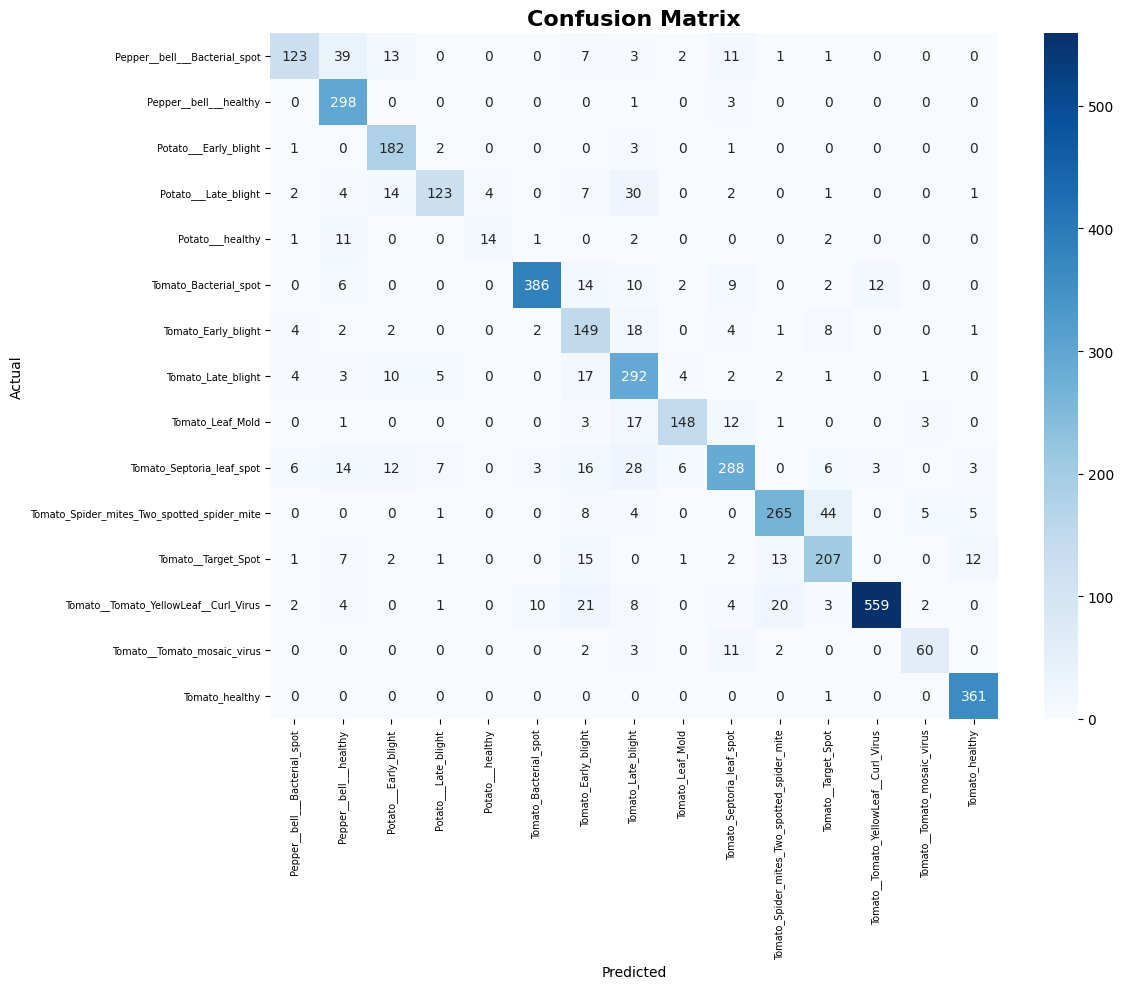

In [16]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

# Predictions nikalo
y_true = []
y_pred = []

for images, labels in test_norm:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(np.argmax(labels.numpy(), axis=1))

# Classification Report
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names,
            cmap='Blues')
plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

In [17]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D

# Pretrained model load karo (ImageNet weights)
base_model = MobileNetV2(
    input_shape=(256, 256, 3),
    include_top=False,
    weights='imagenet'
)

# Base model freeze karo (pehle)
base_model.trainable = False

# Top layers add karo
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
output = Dense(15, activation='softmax')(x)

model_mobilenet = Model(inputs=base_model.input, outputs=output)

model_mobilenet.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_mobilenet.summary()

/tmp/ipykernel_5945/3277215359.py:6: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 128, 128,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 128, 128,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 128, 128,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 128, 128,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 128, 128,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 128, 128,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 128, 128,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 128, 128,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 129, 129,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 64, 64,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 64, 64,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 64, 64,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 64, 64,    │      2,304 │ block_1_depthwis

 Total params: 2,423,887 (9.25 MB)

 Trainable params: 165,903 (648.06 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 70s 96ms/step - accuracy: 0.8350 - loss: 0.5164 - val_accuracy: 0.8987 - val_loss: 0.3024
Epoch 2/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 22s 43ms/step - accuracy: 0.9229 - loss: 0.2351 - val_accuracy: 0.9094 - val_loss: 0.2691
Epoch 3/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 23s 44ms/step - accuracy: 0.9431 - loss: 0.1736 - val_accuracy: 0.9166 - val_loss: 0.2381
Epoch 4/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 22s 43ms/step - accuracy: 0.9570 - loss: 0.1345 - val_accuracy: 0.9200 - val_loss: 0.2403
Epoch 5/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 22s 43ms/step - accuracy: 0.9623 - loss: 0.1136 - val_accuracy: 0.9237 - val_loss: 0.2384
Epoch 6/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 23s 44ms/step - accuracy: 0.9700 - loss: 0.0926 - val_accuracy: 0.9302 - val_loss: 0.2009
Epoch 7/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 40s 43ms/step - accuracy: 0.9785 - loss: 0.0700 - val_accuracy: 0.9319 - val_loss: 0.2185
Epoch 8/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 23s 44ms/step - accuracy: 0.9829 - loss: 0.0524 - 

✅ MobileNetV2 Model saved!


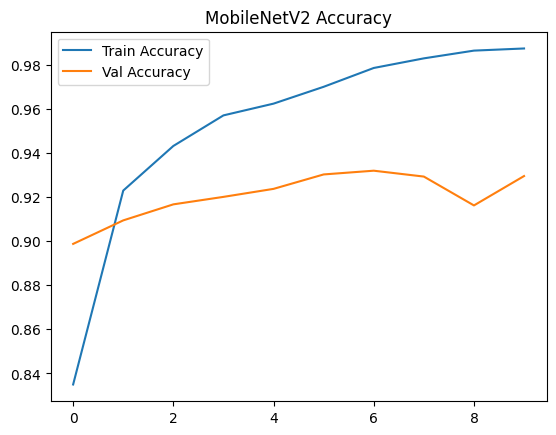

In [18]:
history_mobile = model_mobilenet.fit(
    train_norm,
    epochs=10,
    validation_data=test_norm
)

# Save karo
model_mobilenet.save('mobilenet_plantdisease.h5')
print("✅ MobileNetV2 Model saved!")

# Plot
plt.plot(history_mobile.history['accuracy'], label='Train Accuracy')
plt.plot(history_mobile.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('MobileNetV2 Accuracy')
plt.show()

In [19]:
# CNN final accuracy
cnn_train_acc = max(history.history['accuracy'])
cnn_val_acc = max(history.history['val_accuracy'])

# MobileNetV2 final accuracy
mob_train_acc = max(history_mobile.history['accuracy'])
mob_val_acc = max(history_mobile.history['val_accuracy'])

print("=" * 50)
print(f"{'Model':<20} {'Train Acc':>12} {'Val Acc':>12}")
print("=" * 50)
print(f"{'Custom CNN':<20} {cnn_train_acc*100:>11.2f}% {cnn_val_acc*100:>11.2f}%")
print(f"{'MobileNetV2':<20} {mob_train_acc*100:>11.2f}% {mob_val_acc*100:>11.2f}%")
print("=" * 50)

Model                   Train Acc      Val Acc
Custom CNN                 98.10%       88.10%
MobileNetV2                98.73%       93.19%


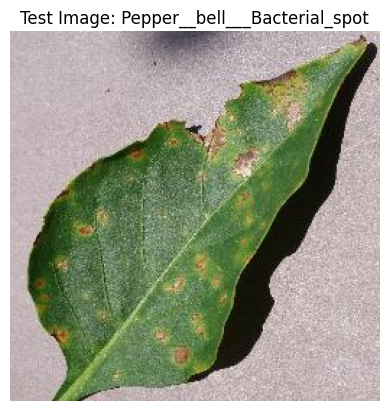

1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step

✅ Actual Class      : Pepper__bell___Bacterial_spot
🌿 Predicted Disease : Pepper__bell___Bacterial_spot
📊 Confidence        : 98.51%


In [23]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# Dataset se hi ek image lo directly
sample_class = class_names[0]  # pehli class
class_path = f'/content/PlantVillage/{sample_class}'
sample_img_name = os.listdir(class_path)[0]
sample_img_path = f'{class_path}/{sample_img_name}'

# Load and show
img = cv2.imread(sample_img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.title(f"Test Image: {sample_class}")
plt.axis('off')
plt.show()

# Resize + normalize
img_resized = cv2.resize(img, (256, 256))
img_norm = img_resized / 255.0
img_input = img_norm.reshape(1, 256, 256, 3)

# MobileNetV2 se prediction
prediction = model_mobilenet.predict(img_input)
predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction) * 100

print(f"\n✅ Actual Class      : {sample_class}")
print(f"🌿 Predicted Disease : {predicted_class}")
print(f"📊 Confidence        : {confidence:.2f}%")